<a href="https://colab.research.google.com/github/beyzahiz/Sentiment-Analysis-NLP/blob/main/04_lstm_deep_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("IMDB Dataset.csv")

In [2]:
df['sentiment'] = df['sentiment'].map({
    'positive':1,
    'negative':0
})

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df['review'],
    df['sentiment'],
    test_size=0.2,
    random_state=42
)

In [4]:
#Tokenizer: Deep learning modelleri kelime indexleri ile çalışır

from tensorflow.keras.preprocessing.text import Tokenizer
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X_train)

#text -> sayı
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [5]:
#Padding: Cümlelerin uzunluğu farklıdır, hepsini aynı boyuta getirmek

from tensorflow.keras.preprocessing.sequence import pad_sequences
max_length = 200

X_train_pad = pad_sequences(X_train_seq, maxlen=max_length)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length)

In [6]:
from tensorflow.keras.layers import Bidirectional, Dropout, GlobalMaxPooling1D
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

model = Sequential()
model.add(Embedding(10000, 128))
model.add(Bidirectional(LSTM(64, return_sequences=True)))  #cümleyi hem baştan sona hem de sondan başa okur
model.add(GlobalMaxPooling1D())  #cümledeki en belirgin özellikleri seçer, karmaşıklığı azaltır, modelin en önemli kelimelere odaklanmasını sağlar
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history = model.fit(
    X_train_pad,
    y_train,
    epochs=4,
    batch_size=64,
    validation_split=0.2
)

loss, accuracy = model.evaluate(X_test_pad, y_test)
print("Test Accuracy: ", accuracy)

Epoch 1/4
500/500 ━━━━━━━━━━━━━━━━━━━━ 219s 424ms/step - accuracy: 0.8033 - loss: 0.4157 - val_accuracy: 0.8800 - val_loss: 0.2854
Epoch 2/4
500/500 ━━━━━━━━━━━━━━━━━━━━ 203s 407ms/step - accuracy: 0.9020 - loss: 0.2471 - val_accuracy: 0.8758 - val_loss: 0.3096
Epoch 3/4
500/500 ━━━━━━━━━━━━━━━━━━━━ 203s 407ms/step - accuracy: 0.9296 - loss: 0.1885 - val_accuracy: 0.8817 - val_loss: 0.2869
Epoch 4/4
500/500 ━━━━━━━━━━━━━━━━━━━━ 208s 417ms/step - accuracy: 0.9467 - loss: 0.1451 - val_accuracy: 0.8714 - val_loss: 0.3259
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.8737 - loss: 0.3144
Test Accuracy:  0.8737000226974487


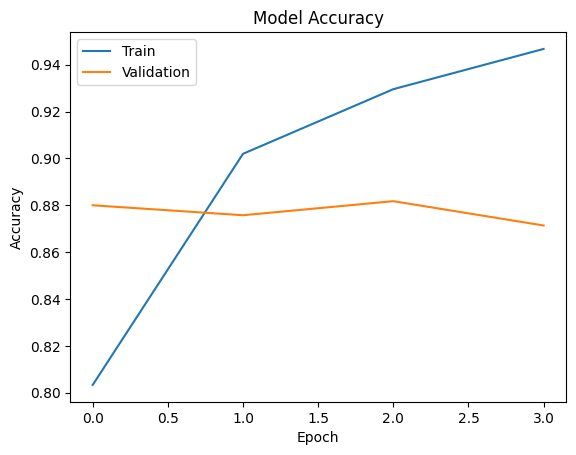

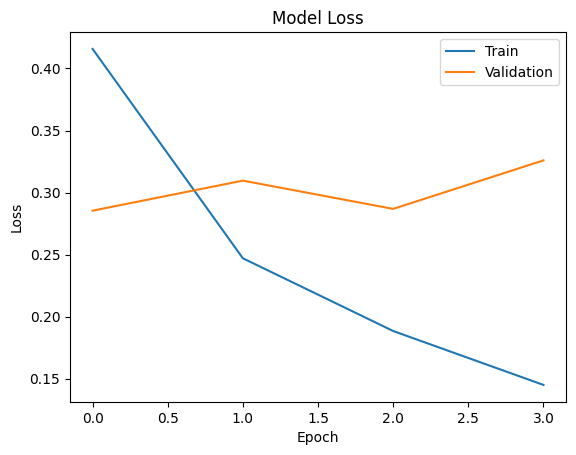

In [7]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Train", "Validation"])
plt.show()

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(["Train", "Validation"])
plt.show()

In [8]:
#GloVe
#Pre-trained Word Embeddings

!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip glove.6B.zip

embeddings_index = {}

with open("glove.6B.100d.txt") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = values[1:]
        embeddings_index[word] = vector

--2026-03-14 11:53:47--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-03-14 11:53:48--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-03-14 11:53:48--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [9]:
len(embeddings_index)

400000

In [10]:
import numpy as np
embedding_dim = 100
word_index = tokenizer.word_index
embedding_matrix = np.zeros((10000, embedding_dim))

In [11]:
for word, i in word_index.items():
  if i >= 10000:
        continue

  vector = embeddings_index.get(word)

  if vector is not None:
        embedding_matrix[i] = np.asarray(vector)

In [12]:
from tensorflow.keras.layers import Embedding

embedding_layer = Embedding(
    input_dim=10000,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    trainable=False
)

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, GlobalMaxPool1D

model = Sequential()
model.add(embedding_layer)
model.add(Bidirectional(LSTM(64, return_sequences=True)))
model.add(GlobalMaxPool1D())
model.add(Dropout(0.5))
model.add(Dense(1, activation="sigmoid"))

model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

history = model.fit(
    X_train_pad,
    y_train,
    epochs=4,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/4
500/500 ━━━━━━━━━━━━━━━━━━━━ 162s 318ms/step - accuracy: 0.7471 - loss: 0.5040 - val_accuracy: 0.8304 - val_loss: 0.3812
Epoch 2/4
500/500 ━━━━━━━━━━━━━━━━━━━━ 165s 330ms/step - accuracy: 0.8304 - loss: 0.3810 - val_accuracy: 0.8497 - val_loss: 0.3433
Epoch 3/4
500/500 ━━━━━━━━━━━━━━━━━━━━ 157s 313ms/step - accuracy: 0.8493 - loss: 0.3470 - val_accuracy: 0.8211 - val_loss: 0.3762
Epoch 4/4
500/500 ━━━━━━━━━━━━━━━━━━━━ 158s 316ms/step - accuracy: 0.8639 - loss: 0.3237 - val_accuracy: 0.8696 - val_loss: 0.3018
